<a href="https://colab.research.google.com/github/saisushanth97/ai-engineer-journey/blob/main/00_customer_recontact_prediction/customer_recontact_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv("bank.csv",sep=";")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [3]:
df.shape

(4521, 17)

In [4]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [6]:
df.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,4521.000000,4521,4521,4521,4521,4521.000000,4521,4521,4521,4521.000000,4521,4521.000000,4521.000000,4521.000000,4521.000000,4521,4521
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,969,2797,2306,4445,NaN,2559,3830,2896,NaN,1398,NaN,NaN,NaN,NaN,3705,4000
mean,41.170095,NaN,NaN,NaN,NaN,1422.657819,NaN,NaN,NaN,15.915284,NaN,263.961292,2.793630,39.766645,0.542579,NaN,NaN
std,10.576211,NaN,NaN,NaN,NaN,3009.638142,NaN,NaN,NaN,8.247667,NaN,259.856633,3.109807,100.121124,1.693562,NaN,NaN
min,19.000000,NaN,NaN,NaN,NaN,-3313.000000,NaN,NaN,NaN,1.000000,NaN,4.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,69.000000,NaN,NaN,NaN,9.000000,NaN,104.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,444.000000,NaN,NaN,NaN,16.000000,NaN,185.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1480.000000,NaN,NaN,NaN,21.000000,NaN,329.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [7]:
df.groupby("y")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,4000.0,226.347500,210.313631,4.0,96.0,167.0,283.0,3025.0
yes,521.0,552.742802,390.325805,30.0,260.0,442.0,755.0,2769.0


In [8]:
pd.crosstab(df["pdays"], df["y"], normalize="index")

y,no,yes
pdays,,
-1,0.909042,0.090958
1,0.000000,1.000000
2,1.000000,0.000000
3,1.000000,0.000000
5,1.000000,0.000000
...,...,...
687,1.000000,0.000000
761,0.000000,1.000000
804,0.000000,1.000000


In [9]:
pd.crosstab([df["job"], df["housing"]],df["y"], normalize="index").sort_values("yes", ascending=False)

,y,no,yes
job,housing,,
unknown,yes,0.000000,1.000000
student,no,0.734375,0.265625
retired,no,0.738889,0.261111
housemaid,no,0.835616,0.164384
unknown,no,0.837838,0.162162
admin.,no,0.840909,0.159091
unemployed,no,0.842857,0.157143
management,no,0.843348,0.156652
self-employed,no,0.852632,0.147368


In [10]:
df.groupby("y")["balance"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
y,,,,,
no,4000,1403.211750,419.5,-3313,71188
yes,521,1571.955854,710.0,-1206,26965


In [11]:
df.groupby("y")["balance"].quantile([0.25, 0.75])

y        
no   0.25      61.0
     0.75    1407.0
yes  0.25     171.0
     0.75    2160.0
Name: balance, dtype: float64

In [12]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
y=df["y"]
x=df.drop("y", axis=1)

In [15]:
x=x.drop("duration",axis=1)

In [16]:
y=y.map({"yes":1,"no":0})

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((3616, 15), (905, 15), (3616,), (905,))

In [19]:
numerical_features=x_train.select_dtypes(include="number").columns
categorical_features=x_train.select_dtypes(exclude="number").columns

In [20]:
preprocessor=ColumnTransformer(
    [
        ("numerical_preprocessor", StandardScaler(), numerical_features),
        ("categorical_preprocessor", OneHotEncoder(drop="first"), categorical_features),
    ]
)

In [21]:
x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)

In [22]:
model = LogisticRegression()
model.fit(x_train_processed, y_train)

LogisticRegression()

In [23]:
y_pred=model.predict(x_test_processed)

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

In [25]:
accuracy,conf_matrix,precision,recall,f1

(0.8883977900552487,
 array([[788,  13],
        [ 88,  16]]),
 0.5517241379310345,
 0.15384615384615385,
 0.24060150375939848)

In [26]:
y_prob = model.predict_proba(x_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

np.float64(0.7366032843560933)

In [27]:
y_pred_30 = (y_prob >= 0.30).astype(int)
y_pred_30

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [28]:
p=precision_score(y_test, y_pred_30)
r=recall_score(y_test, y_pred_30)
f1=f1_score(y_test, y_pred_30)

In [29]:
p,r,f1

(0.45614035087719296, 0.25, 0.32298136645962733)

In [30]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 49)

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    p_t = precision_score(y_test, preds, zero_division=0)
    r_t = recall_score(y_test, preds, zero_division=0)
    f1_t = f1_score(y_test, preds, zero_division=0)
    print(f"{t:<10.1f} | {p_t:<10.4f} | {r_t:<10.4f} | {f1_t:<10.4f}")

Threshold  | Precision  | Recall     | F1-Score  
-------------------------------------------------
0.1        | 0.1995     | 0.7019     | 0.3106    
0.2        | 0.3627     | 0.3558     | 0.3592    
0.3        | 0.4561     | 0.2500     | 0.3230    
0.4        | 0.4524     | 0.1827     | 0.2603    
0.5        | 0.5517     | 0.1538     | 0.2406    
0.6        | 0.7647     | 0.1250     | 0.2149    
0.7        | 0.7000     | 0.0673     | 0.1228    


In [31]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print(pr_auc)

0.32826071602891804


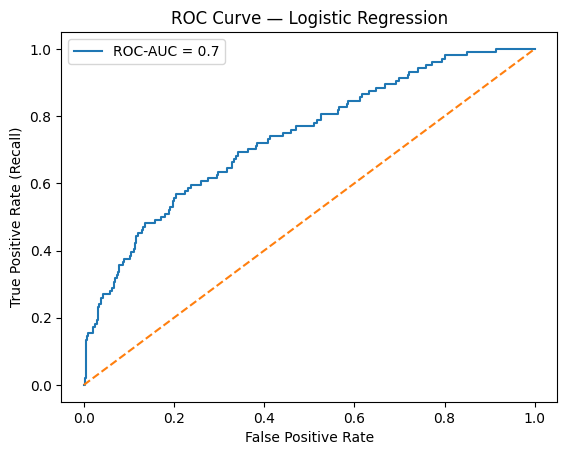

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.1f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

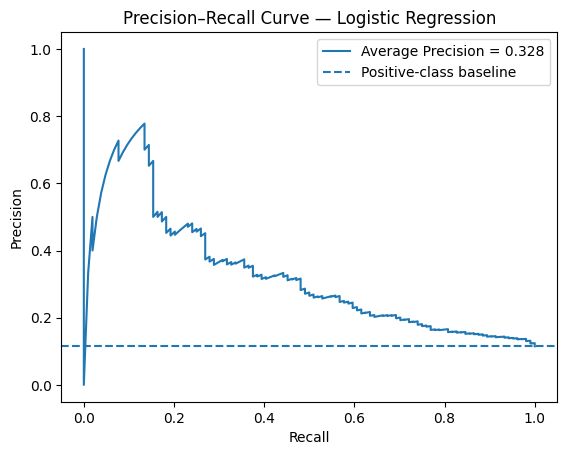

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f"Average Precision = {pr_auc:.3f}")
plt.axhline(
    y_test.mean(),
    linestyle="--",
    label="Positive-class baseline"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Logistic Regression")
plt.legend()
plt.show()

Started to compare the base logistic regression model with other similar concepts

In [34]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_processed, y_train)

dt_pred = dt_model.predict(x_test_processed)
dt_prob = dt_model.predict_proba(x_test_processed)[:, 1]


In [35]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score

In [36]:
print("Accuracy: ",accuracy_score(y_test, dt_pred))
print("Precision: ",precision_score(y_test, dt_pred,zero_division=0))
print("Recall: ",recall_score(y_test, dt_pred,zero_division=0))
print("F1 Score: ",f1_score(y_test, dt_pred,zero_division=0))
print("ROC AUC Score: ",roc_auc_score(y_test, dt_prob))
print("Average Precision Score: ",average_precision_score(y_test, dt_prob))



Accuracy:  0.8198895027624309
Precision:  0.2601626016260163
Recall:  0.3076923076923077
F1 Score:  0.28193832599118945
ROC AUC Score:  0.5970421588399116
Average Precision Score:  0.15960804231926723


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train_processed, y_train)

rf_pred = rf_model.predict(x_test_processed)
rf_prob = rf_model.predict_proba(x_test_processed)[:, 1]

In [38]:
print("Accuracy : ",accuracy_score(y_test, rf_pred))
print("Precision : ",precision_score(y_test, rf_pred,zero_division=0))
print("Recall : ",recall_score(y_test, rf_pred,zero_division=0))
print("F1 Score : ",f1_score(y_test, rf_pred,zero_division=0))
print("ROC AUC Score : ",roc_auc_score(y_test, rf_prob))
print("Average Precision Score : ",average_precision_score(y_test, rf_prob))

Accuracy :  0.8850828729281768
Precision :  0.5
Recall :  0.11538461538461539
F1 Score :  0.1875
ROC AUC Score :  0.6970253529242294
Average Precision Score :  0.28448781025354086


In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train_processed, y_train)

gb_pred = gb_model.predict(x_test_processed)
gb_prob = gb_model.predict_proba(x_test_processed)[:, 1]

In [40]:
print("Accuracy : ",accuracy_score(y_test, gb_pred))
print("Precision : ",precision_score(y_test, gb_pred,zero_division=0))
print("Recall : ",recall_score(y_test, gb_pred,zero_division=0))
print("F1 Score : ",f1_score(y_test, gb_pred,zero_division=0))
print("ROC AUC Score : ",roc_auc_score(y_test, gb_prob))
print("Average Precision Score : ",average_precision_score(y_test, gb_prob))

Accuracy :  0.8895027624309392
Precision :  0.5555555555555556
Recall :  0.19230769230769232
F1 Score :  0.2857142857142857
ROC AUC Score :  0.746332709113608
Average Precision Score :  0.3357738669042789


In [41]:
gb_prob = gb_model.predict_proba(x_test_processed)[:, 1]

gb_pred_02 = (gb_prob >= 0.2).astype(int)

print("Precision:", precision_score(y_test, gb_pred_02))
print("Recall:", recall_score(y_test, gb_pred_02))
print("F1:", f1_score(y_test, gb_pred_02))

Precision: 0.37735849056603776
Recall: 0.38461538461538464
F1: 0.38095238095238093
